In [12]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from rag.rag_system_universal_v2 import UniversalBabyOSRetriever
# sys.path.insert(0, str(Path.cwd().parent))
load_dotenv()

from agents.state      import BabyOSState, make_initial_state, week_to_phase
from agents.supervisorv2 import supervisor_node
from agents.agentsv2     import (
    medical_agent, tracker_agent, emotional_agent,
    parent_agent, hebamme_agent, germany_agent,
)
from agents.vision     import vision_node

DEBUG_MODE = os.getenv("DEBUG_MODE")

In [13]:
# ── Retriever singleton — lazy-loaded ─────────────────────────────────────────

_retriever = None

def _get_retriever():
    """
    Lazy-load the universal BabyOS retriever.

    Architecture:
    - Single collection: babyos_universal
    - Metadata filtering:
        topic
        period
        section
        source_type
    """

    global _retriever

    if _retriever is None:
        from rag.rag_system_universal_v2 import UniversalBabyOSRetriever

        _retriever = UniversalBabyOSRetriever(
            k_candidates=25,
            k_final=6,
            use_hyde=True,
            use_reranker=True,
        )

    return _retriever


In [14]:
# ── Node 1: input_node ────────────────────────────────────────────────────────

def input_node(state: BabyOSState) -> dict:
    """
    Runs first on every turn.
    - Extracts the latest HumanMessage as current_query
    - Refreshes per-turn shortcut fields from user_profile
    - Resets all per-turn output fields to clean state
    """
    messages = state.get("messages", [])
    profile  = state.get("user_profile", {})

    # Extract latest human message
    current_query = ""
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            current_query = msg.content
            break
        if isinstance(msg, dict) and msg.get("role") == "human":
            current_query = msg.get("content", "")
            break

    week  = profile.get("current_week", 20)
    pp    = profile.get("postpartum_weeks", 0)
    phase = week_to_phase(week, pp)

    return {
        "current_query":      current_query,
        "current_week":       week,
        "postpartum_weeks":   pp,
        "current_phase":      phase,
        "user_role":          profile.get("role", "mom"),
        # Reset per-turn fields
        "agent_response":     "",
        "agent_name":         "",
        "danger_flag":        False,
        "danger_reason":      None,
        "retrieved_context":  "",
        "retrieved_sources":  [],
        "retrieval_metadata": [],
        # Preserve image fields if set by caller (don't reset them here)
    }


In [15]:
# ── Node 2: vision_node (conditional) ────────────────────────────────────────
# The actual vision_node function lives in agents/vision.py.
# We wrap it so the graph can skip it entirely when no image is present.

def maybe_vision_node(state: BabyOSState) -> dict:
    """
    Runs GPT-4o Vision only when an image was uploaded.
    Returns {} (no-op) if no image in state.
    """
    if not state.get("uploaded_image_b64"):
        return {}
    return vision_node(state)


In [16]:
# ── Node 3: supervisor_node ───────────────────────────────────────────────────
# Imported from agents/supervisor.py
# Sets: next_agent, danger_flag, run_metadata.routed_topic


In [17]:
# # ── Node 4: retriever_node ────────────────────────────────────────────────────

# def retriever_node(state: BabyOSState) -> dict:
#     """
#     Runs AFTER supervisor so routed_topic is already in run_metadata.
#     Calls BabyOSRetriever.retrieve() with topic + period filter.
#     Writes retrieved_context and retrieved_sources into state.
#     """
#     query = state["current_query"]
#     week  = state["current_week"]
#     pp    = state["postpartum_weeks"]
#     role  = state["user_role"]
#     phase = state["current_phase"]

#     if not query.strip():
#         return {"retrieved_context": "", "retrieved_sources": []}

#     # Get topic hint set by supervisor
#     run_meta     = state.get("run_metadata", {})
#     routed_topic = run_meta.get("routed_topic")

#     # Derive period from week or postpartum weeks
#     from rag.taxonomy import week_to_pregnancy_month, postpartum_weeks_to_period
#     if pp > 0:
#         period  = postpartum_weeks_to_period(pp)
#         section = "postpartum"
#         # Prefix query with postpartum context for better embedding
#         effective_query = f"[postpartum {round(pp/4.33,1)} months] {query}"
#     else:
#         period  = week_to_pregnancy_month(week) if week else None
#         section = "pregnancy"
#         effective_query = query

#     try:
#         retriever = _get_retriever()
#         docs      = retriever.retrieve(
#             query=effective_query,
#             topic=routed_topic,
#             period=period,
#             section=section,
#             week=week if pp == 0 else None,
#             role=role,
#             phase=phase,
#         )
#         context = retriever.format_context(docs)
#         sources = list({
#             d.metadata.get("source_name", d.metadata.get("source_file", "?"))
#             for d in docs
#         })
#     except Exception as e:
#         print(f"[retriever_node] Warning: {e}")
#         context = "Knowledge base temporarily unavailable."
#         sources = []

#     return {
#         "retrieved_context": context,
#         "retrieved_sources": sources,
#     }


In [18]:
# ── Node 4: retriever_node ────────────────────────────────────────────────────

def retriever_node(state: BabyOSState) -> dict:
    """
    Universal metadata-aware retrieval node.

    Uses:
    - topic filtering
    - pregnancy/postpartum period filtering
    - optional week filtering
    - HyDE + BM25 + reranker

    Stores:
    - retrieved_context
    - retrieved_sources
    - retrieval_metadata
    """

    query = state.get("current_query", "").strip()

    if not query:
        return {
            "retrieved_context": "",
            "retrieved_sources": [],
            "retrieval_metadata": [],
        }

    week = state.get("current_week")
    postpartum_weeks = state.get("postpartum_weeks", 0)

    # Supervisor metadata
    run_meta = state.get("run_metadata", {})
    routed_topic = run_meta.get("routed_topic")

    # Optional vision-derived retrieval hints
    vision_topic = state.get("vision_detected_topic")

    # Vision can override topic if available
    if vision_topic:
        routed_topic = vision_topic

    # Derive retrieval period
    from rag.taxonomy import (
        week_to_pregnancy_month,
        postpartum_weeks_to_period,
    )

    if postpartum_weeks > 0:
        period = postpartum_weeks_to_period(postpartum_weeks)
        section = "postpartum"

        effective_query = (
            f"[postpartum {round(postpartum_weeks / 4.33, 1)} months] "
            f"{query}"
        )

    else:
        period = (
            week_to_pregnancy_month(week)
            if week
            else None
        )

        section = "pregnancy"
        effective_query = query

    try:
        retriever = _get_retriever()

        # Primary retrieval
        # docs = retriever.retrieve(
        #     query=effective_query,
        #     topic=routed_topic,
        #     period=period,
        #     section=section,
        #     week=week if postpartum_weeks == 0 else None,
        # )
        docs = retriever.debug_query(
            query=effective_query,
            topic=routed_topic,
            period=period,
            section=section,
            week=week if postpartum_weeks == 0 else None,
        )

        # Fallback retrieval if filters over-constrain
        if not docs:
            docs = retriever.retrieve(
                query=effective_query
            )

        # Format context
        context = retriever.format_context(docs)

        # Prevent token explosion
        MAX_CONTEXT_CHARS = 12000
        context = context[:MAX_CONTEXT_CHARS]

        # Sources
        sources = list({
            d.metadata.get(
                "source_name",
                d.metadata.get("source_file", "?")
            )
            for d in docs
        })

        # Retrieval metadata
        retrieval_metadata = []

        for d in docs:
            retrieval_metadata.append({
        "source_name":  d.metadata.get("source_name", "Unknown"),
        "source_type":  d.metadata.get("source_type", ""),
        "source_file":  d.metadata.get("source_file", ""),
        "topic":        d.metadata.get("topic", ""),
        "period":       d.metadata.get("period", ""),
        "section":      d.metadata.get("section", ""),
        "rerank_score": d.metadata.get("rerank_score"),
        "final_score":  d.metadata.get("final_score"),
        "video_id":     d.metadata.get("video_id"),
        "youtube_url":  d.metadata.get("youtube_url"),
        "timestamp":    d.metadata.get("timestamp"),
        "video_label":  d.metadata.get("video_label", ""),
        "snippet":      d.page_content[:300],
    })

    except Exception as e:

        print(f"[retriever_node] Warning: {e}")

        context = "Knowledge base temporarily unavailable."
        sources = []
        retrieval_metadata = []

    return {
        "retrieved_context": context,
        "retrieved_sources": sources,
        "retrieval_metadata": retrieval_metadata,
    }

In [19]:
# ── Node 5: output_node ───────────────────────────────────────────────────────

def output_node(state: BabyOSState) -> dict:
    """
    Post-processes agent response:
    - Prepends danger banner if danger_flag=True and no 112 mention yet
    - Appends Born Together attribution
    - Updates run_metadata for LangSmith tracing
    """
    response    = state.get("agent_response", "")
    agent_name  = state.get("agent_name", "BabyOS")
    danger_flag = state.get("danger_flag", False)

    if danger_flag and "112" not in response:
        banner = (
            "🚨 **Seek medical attention immediately.**\n"
            "Call **112** (emergency) · **116 117** (urgent non-emergency) · "
            "or go directly to your **Kreißsaal** / **Notaufnahme**.\n\n"
        )
        response = banner + response

    response = response.rstrip()
    response += f"\n\n<small>*{agent_name} · Born Together 🌱*</small>"

    return {
        "agent_response": response,
        "run_metadata": {
            **state.get("run_metadata", {}),
            "agent_name":  agent_name,
            "danger_flag": danger_flag,
            "phase":       state.get("current_phase"),
            "role":        state.get("user_role"),
            "topic":       state.get("run_metadata", {}).get("routed_topic"),
            "retrieval_metadata": state.get("retrieval_metadata", []),
        },
    }

In [20]:
# ── Conditional edge function ─────────────────────────────────────────────────

def route_to_agent(state: BabyOSState) -> str:
    """Read next_agent from state (set by supervisor) and return the node name."""
    return state.get("next_agent", "medical_agent")


In [21]:
# ── Graph assembly ─────────────────────────────────────────────────────────────

def build_graph():
    builder = StateGraph(BabyOSState)

    # Register all nodes
    builder.add_node("input_node",      input_node)
    builder.add_node("vision_node",     maybe_vision_node)
    builder.add_node("supervisor_node", supervisor_node)
    builder.add_node("retriever_node",  retriever_node)
    builder.add_node("medical_agent",   medical_agent)
    builder.add_node("tracker_agent",   tracker_agent)
    builder.add_node("emotional_agent", emotional_agent)
    builder.add_node("parent_agent",    parent_agent)
    builder.add_node("hebamme_agent",   hebamme_agent)
    builder.add_node("germany_agent",   germany_agent)
    builder.add_node("output_node",     output_node)

    # Fixed linear edges
    builder.add_edge(START,             "input_node")
    builder.add_edge("input_node",      "vision_node")
    builder.add_edge("vision_node",     "supervisor_node")   # ← supervisor BEFORE retriever
    builder.add_edge("supervisor_node", "retriever_node")    # ← retriever uses supervisor's topic
    # builder.add_edge("retriever_node",  "supervisor_node")   # ← this line is WRONG, see below

    # Oops — remove that last line. Conditional edge from retriever:
    # Actually: conditional edge is FROM supervisor, not retriever.
    # Retriever always leads to the conditional agent dispatch.
    # Let's fix the wiring properly:

    # The graph is:
    #   retriever_node → conditional(next_agent) → one of the agents → output_node
    builder.add_conditional_edges(
        "retriever_node",
        route_to_agent,
        {
            "medical_agent":   "medical_agent",
            "tracker_agent":   "tracker_agent",
            "emotional_agent": "emotional_agent",
            "parent_agent":    "parent_agent",
            "hebamme_agent":   "hebamme_agent",
            "germany_agent":   "germany_agent",
            "FINISH":          "output_node",
        }
    )

    # All agents converge to output_node
    for agent in ["medical_agent", "tracker_agent", "emotional_agent",
                  "parent_agent", "hebamme_agent", "germany_agent"]:
        builder.add_edge(agent, "output_node")

    builder.add_edge("output_node", END)

    # MemorySaver enables cross-turn memory keyed by thread_id
    memory = MemorySaver()
    return builder.compile(checkpointer=memory)

In [22]:
# ── Singleton graph ────────────────────────────────────────────────────────────

_graph = None

def get_graph():
    global _graph
    if _graph is None:
        _graph = build_graph()
    return _graph


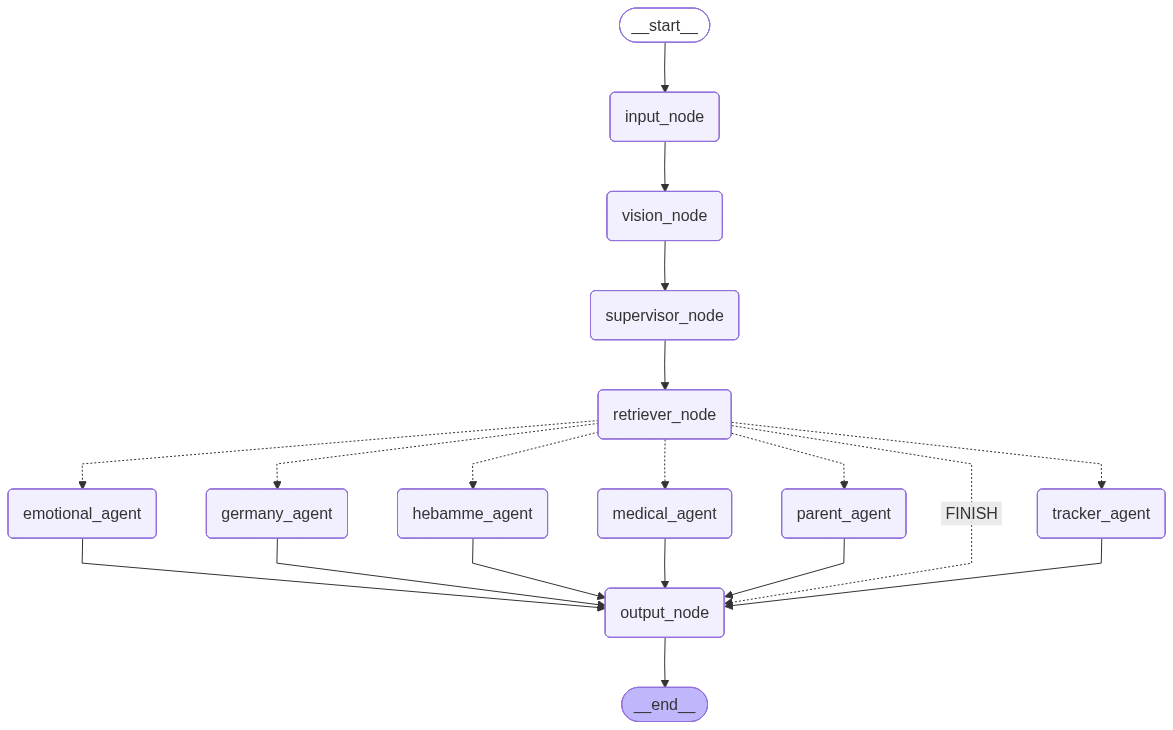

In [23]:
def get_graph():
    global _graph
    if _graph is None:
        _graph = build_graph()
    return _graph

from IPython.display import Image, display


graph=get_graph()
display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
# ── Public chat() entry point — called by backend/main.py ─────────────────────

def chat(
    message:    str,
    state:      BabyOSState,
    thread_id:  str = "default",
    image_b64:  str = None,
    image_type: str = None,
) -> tuple[str, BabyOSState]:
    """
    Main entry point for the FastAPI backend.

    Args:
        message:    The user's text message
        state:      Current BabyOSState (built from Supabase profile + history)
        thread_id:  Unique session ID — use Supabase user_id
        image_b64:  Optional base64 image (Mutterpass, ultrasound, etc.)
        image_type: Document type hint — "mutterpass"|"ultrasound"|"blood_report"|
                    "urine_report"|"ctg"|"other_scan"|"other"

    Returns:
        (response_text, updated_state)
    """
    graph  = get_graph()
    config = {"configurable": {"thread_id": thread_id}}

    # Append the new human message
    input_state: BabyOSState = {
        **state,
        "messages": list(state.get("messages", [])) + [HumanMessage(content=message)],
    }

    # Inject image if provided
    if image_b64:
        input_state["uploaded_image_b64"]  = image_b64
        input_state["uploaded_image_type"] = image_type or "other"

    result = graph.invoke(input_state, config=config)
    return result["agent_response"], result

In [ ]:
user_profile={
    "current_week":20,
    "postpartum_weeks":0,
    "role":"mom",
    }

init_state = make_initial_state(user_profile)

print(init_state)

In [28]:
print(init_state)

{'messages': [], 'user_profile': {'current_week': 20, 'postpartum_weeks': 0, 'role': 'mom', 'phase': 'T2'}, 'current_query': '', 'current_week': 20, 'postpartum_weeks': 0, 'current_phase': 'T2', 'user_role': 'mom', 'next_agent': 'FINISH', 'retrieved_context': '', 'retrieved_sources': [], 'agent_response': '', 'agent_name': '', 'danger_flag': False, 'danger_reason': None, 'uploaded_image_b64': None, 'uploaded_image_type': None, 'last_document_analysis': None, 'timeline_logs': [], 'run_metadata': {}}


In [26]:

response = chat(
    message="Is it normal to feel short of breath during pregnancy",
    state=init_state
)

print(response)

[RAG] Loading: babyos_universal
QUERY: Is it normal to feel short of breath during pregnancy
[RAG] Tier 0 ({'section': 'pregnancy'}): 20 docs
[RAG] Final: 6 docs (tier=0, topic=None, period=pregnancy_m5)

Retrieved: 6 docs

[1] Topic: fetal_movement
     Period: pregnancy_m9
     Source: WHO (pdf)
     Score : 0.5  (rerank=None, weight=1.0, bonus=0.0)
     Text  : DIFFICULTY IN BREATHING  S-149 
 
PROBLEM 
• A woman is short of breath during pregnancy, labour or after giving 
birth. 
 
 
IMMEDIATE MANAGEMENT 
• Perform a rapid evaluation of the woman’s general 
--------------------------------------------------------------------------------
[2] Topic: pregnancy_workout
     Period: all
     Source: NHS (web)
     Score : 0.49  (rerank=None, weight=0.98, bonus=0.0)
     Text  : . If in doubt, consult your maternity team. As a general rule, you should be able to hold a conversation as you exercise when pregnant. If you become breathless as you talk, then you're probably exerc
-----------

In [27]:
# debug#1

QSTN_TEST=[
    "Is it normal to feel short of breath during pregnancy",
    "Is itching with discharge normal or dangerous",
    "Why does vaginal discharge increase in pregnancy",
    "How much coffee is allowed in pregnancy per day",
    "Is it safe to fly during pregnancy",
    "Why do my feet and ankles swell in pregnancy",
    "Why do i get blurry vision or nausea with low bp",
    "Why do i have moodswings",
    "Is L4,l5 backpain is normal in pregnancy",
    "Is physiotherapy safe during pregnancy",
    "Can baby position affect nerve pain",
    "Can i take painkillers during prgnancy",
    "Could low oxygen levels permanently affect the baby",
    "Could spinal problems worsen during pregnancy",
    "What causes premature birth",
    "Could low Bp affect the baby's growth",
    "Is Sex safe during Pregnancy",
    "How can i support my partner",
    "what kind of foods can i eat",
    "What should dads prepare during week 30?"
]

for q in QSTN_TEST:
    response = chat(
    message=q,
    state=init_state
    )   
    print(response)
    print("------------------------------------------------------------------------")

QUERY: Is it normal to feel short of breath during pregnancy
[RAG] Tier 0 ({'section': 'pregnancy'}): 20 docs
[RAG] Final: 6 docs (tier=0, topic=None, period=pregnancy_m5)

Retrieved: 6 docs

[1] Topic: fetal_movement
     Period: pregnancy_m9
     Source: WHO (pdf)
     Score : 0.5  (rerank=None, weight=1.0, bonus=0.0)
     Text  : DIFFICULTY IN BREATHING  S-149 
 
PROBLEM 
• A woman is short of breath during pregnancy, labour or after giving 
birth. 
 
 
IMMEDIATE MANAGEMENT 
• Perform a rapid evaluation of the woman’s general 
--------------------------------------------------------------------------------
[2] Topic: pregnancy_workout
     Period: all
     Source: NHS (web)
     Score : 0.49  (rerank=None, weight=0.98, bonus=0.0)
     Text  : . If in doubt, consult your maternity team. As a general rule, you should be able to hold a conversation as you exercise when pregnant. If you become breathless as you talk, then you're probably exerc
-------------------------------------------